<h1>Frequency Domain Steganography</h1>

### Necessary Imports & Declarations

In [2]:
import os
import glob
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import random
#matplotlib inline

from PIL import Image
from torchvision import transforms
from skimage.filters import threshold_otsu

from deepgaze.saliency_map import FasaSaliencyMapping

# Define the directory paths
train_dir = os.path.join("data", "imagenet", "train")
val_dir   = os.path.join("data", "imagenet", "val")

### Preview function to see output of each step.

In [3]:
# train_dir = os.path.join("data", "imagenet", "train")

def get_sample_images(directory, n=5):
    image_paths = glob.glob(os.path.join(directory, '*.*'))
    if len(image_paths) < n:
        return image_paths
    return random.sample(image_paths, n)

sample_image_paths = get_sample_images(train_dir, n=5)
sample_images = []
titles = []

### Load and Preprocess Images

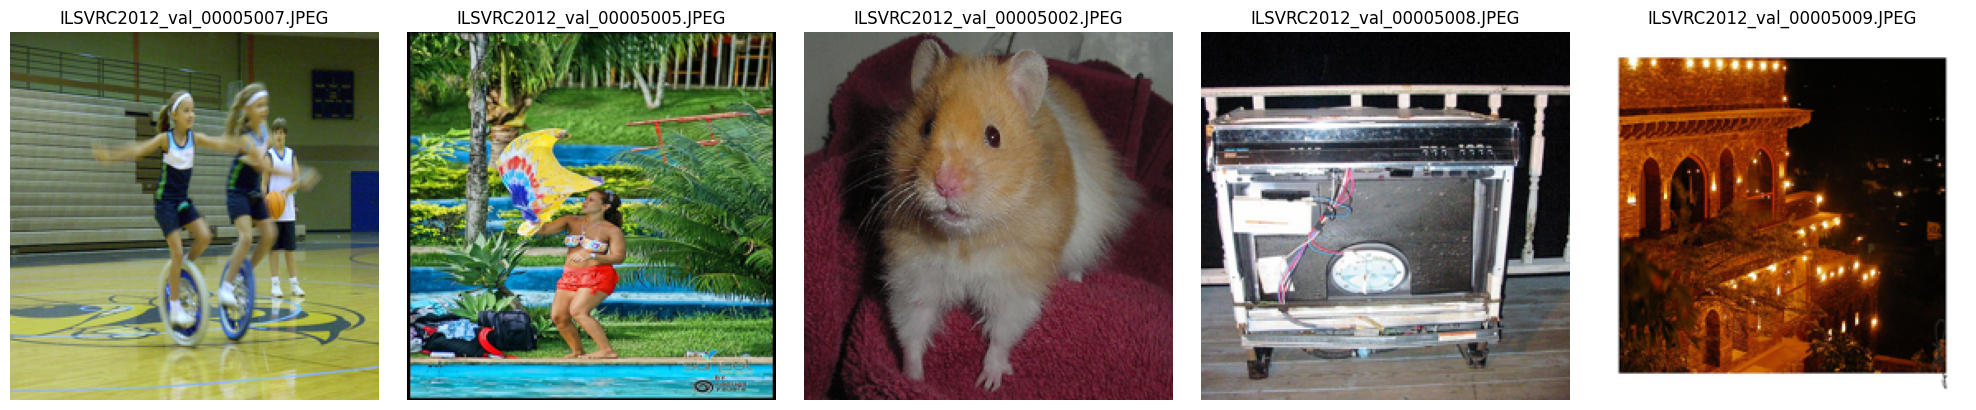

In [4]:
# Load each image, convert to RGB, resize to 224x224, and normalize to [0,1]
for path in sample_image_paths:
    try:
        img = Image.open(path).convert("RGB")
        img = img.resize((224, 224))
        sample_images.append(np.array(img) / 255.0)
        titles.append(os.path.basename(path))
    except Exception as e:
        print(f"Error loading {path}: {e}")

# Display the resized original images horizontally
fig, axes = plt.subplots(1, len(sample_images), figsize=(len(sample_images) * 4, 4))
for ax, img, title in zip(axes, sample_images, titles):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

### DeepGaze Saliency Mapping

Processing image 1: shape (224, 224, 3), min 0, max 255
Processing image 2: shape (224, 224, 3), min 0, max 255
Processing image 3: shape (224, 224, 3), min 1, max 201
Processing image 4: shape (224, 224, 3), min 0, max 255
Processing image 5: shape (224, 224, 3), min 0, max 255


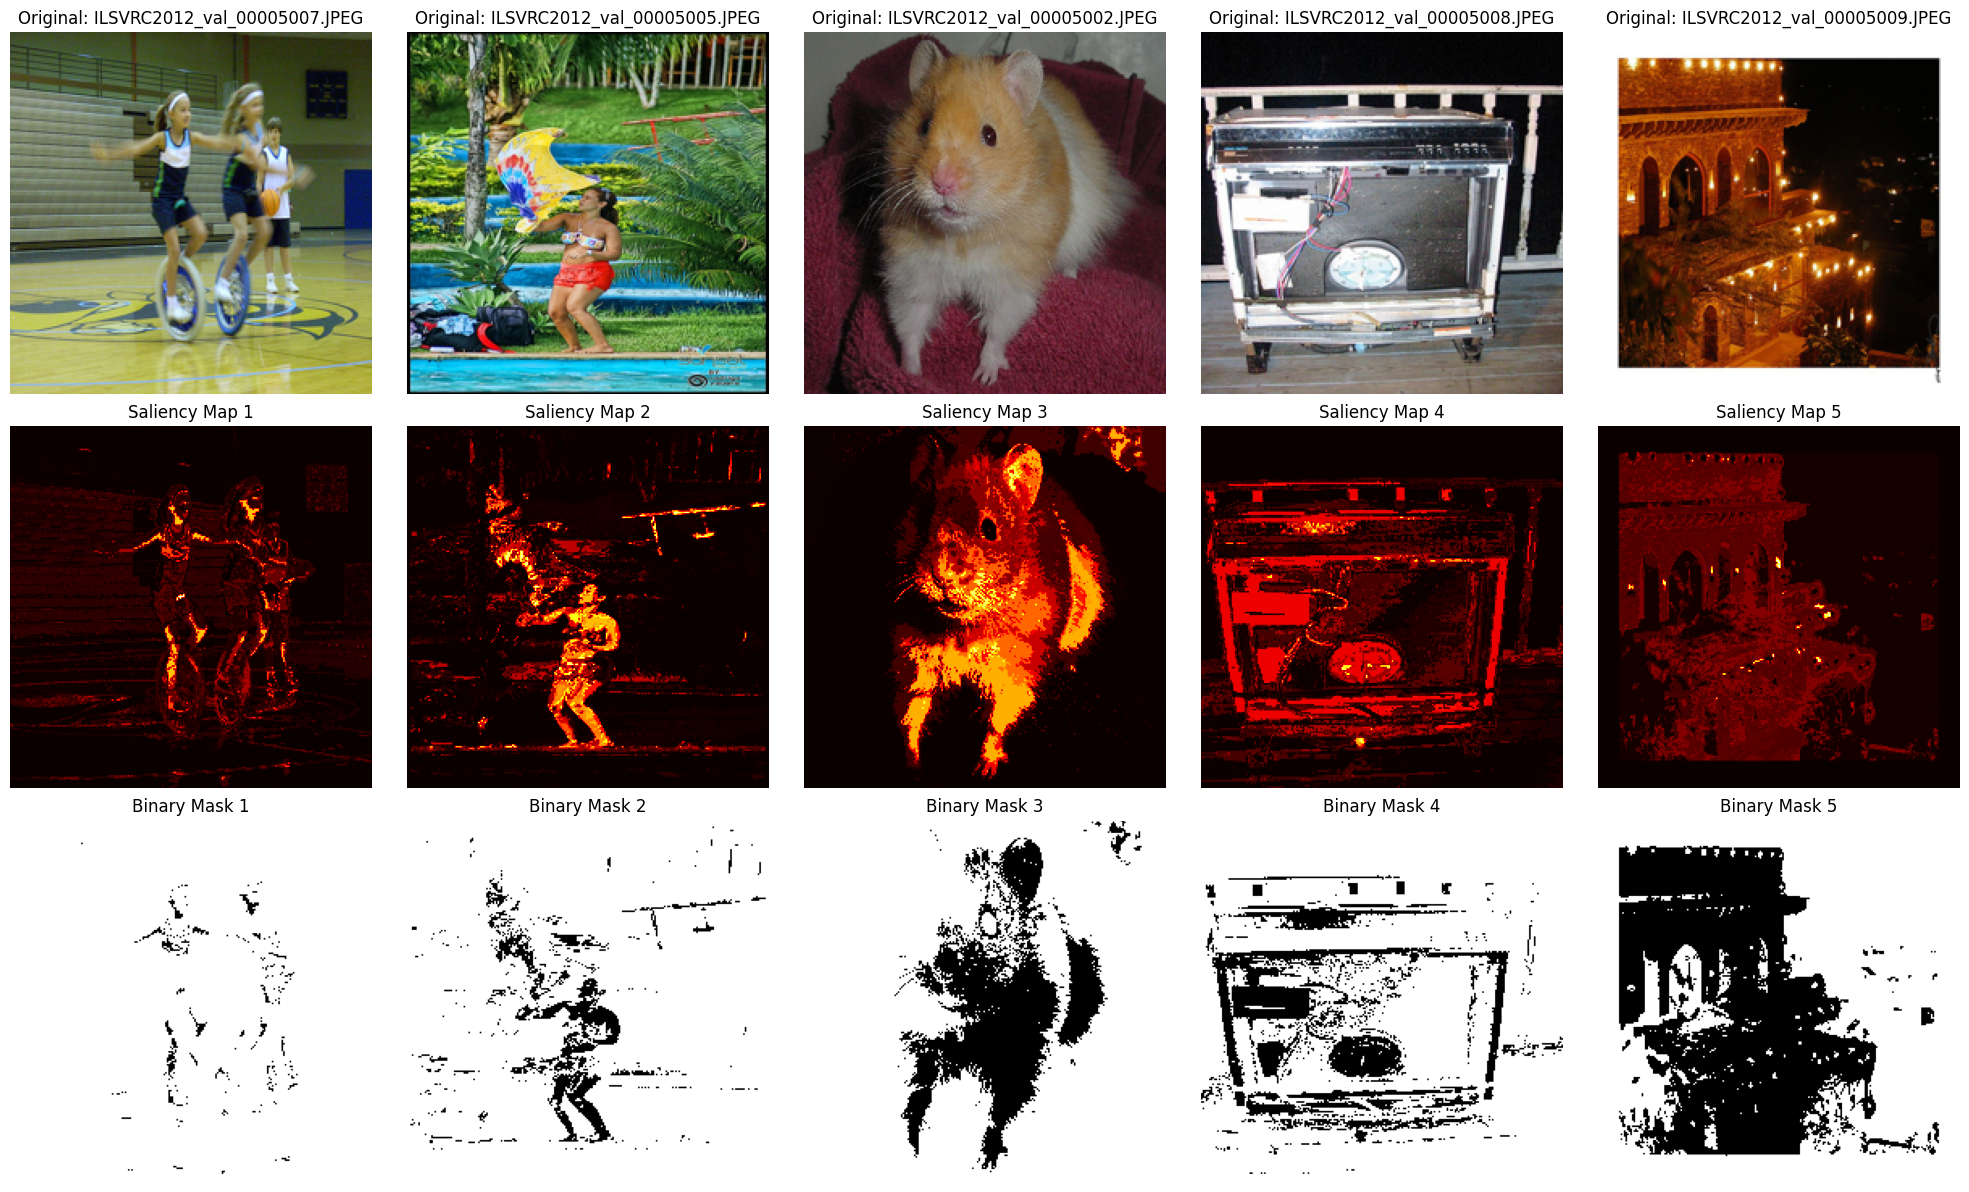

In [5]:
def gen_saliency_maps(images):
    saliency_maps = []
    for idx, img in enumerate(images):
        # Instantiate a new saliency model for each image (avoids caching/state issues)
        saliency = FasaSaliencyMapping(image_h=224, image_w=224)
        # Convert normalized image (0–1) to uint8 (0–255)
        image_uint8 = (img * 255).astype(np.uint8)
        # (Image is already 224×224)
        print(f"Processing image {idx+1}: shape {image_uint8.shape}, min {image_uint8.min()}, max {image_uint8.max()}")
        sal_map = saliency.returnMask(image_uint8, tot_bins=8, format='RGB')
        saliency_maps.append(sal_map)
    return np.array(saliency_maps)

# Generate saliency maps for our sample images
saliency_maps = gen_saliency_maps(sample_images)

# For each saliency map, create a binary mask using Otsu's thresholding and display the results.
binary_masks = []
fig, axes = plt.subplots(3, len(sample_images), figsize=(len(sample_images)*4, 12))
for i, (img, sal_map) in enumerate(zip(sample_images, saliency_maps)):
    # Normalize saliency map to [0,255] for visualization
    sal_map_norm = cv2.normalize(sal_map, None, 0, 255, cv2.NORM_MINMAX).astype('uint8')
    thresh_val = threshold_otsu(sal_map_norm)
    binary_mask = (sal_map_norm < thresh_val).astype(np.uint8) * 255
    binary_masks.append(binary_mask)
    
    # Row 0: Original image (resized)
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Original: {titles[i]}")
    axes[0, i].axis('off')
    # Row 1: Saliency Map
    axes[1, i].imshow(sal_map_norm, cmap='hot')
    axes[1, i].set_title(f"Saliency Map {i+1}")
    axes[1, i].axis('off')
    # Row 2: Binary Mask
    axes[2, i].imshow(binary_mask, cmap='gray')
    axes[2, i].set_title(f"Binary Mask {i+1}")
    axes[2, i].axis('off')
plt.tight_layout()
plt.show()

<h2>Frequency Domain Embedding (DCT)</h2>

In [6]:
# # Helper function: Convert an RGB image (normalized) to grayscale and apply its binary mask.
# def convert_to_gray_and_apply_mask(img, binary_mask):
#     # Convert image to uint8 (0–255) and then to grayscale
#     img_uint8 = (img * 255).astype(np.uint8)
#     gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)
#     # Apply binary mask (which is assumed to be 224×224)
#     masked = cv2.bitwise_and(gray, gray, mask=binary_mask)
#     return masked

# # Process each sample image using its corresponding binary mask
# masked_grays = []
# for img, mask in zip(sample_images, binary_masks):
#     masked_gray = convert_to_gray_and_apply_mask(img, mask)
#     masked_grays.append(masked_gray)

# # Display the masked grayscale images
# fig, axes = plt.subplots(1, len(masked_grays), figsize=(len(masked_grays)*4, 4))
# for ax, mg, title in zip(axes, masked_grays, titles):
#     ax.imshow(mg, cmap='gray')
#     ax.set_title(title)
#     ax.axis('off')
# plt.tight_layout()
# plt.show()


In [7]:
# def split_into_blocks(img, block_size):
#     h, w = img.shape
#     blocks = []
#     for i in range(0, h - block_size + 1, block_size):
#         for j in range(0, w - block_size + 1, block_size):
#             block = img[i:i+block_size, j:j+block_size]
#             blocks.append(block)
#     return blocks

# # For demonstration, split the first masked grayscale image into 8×8 blocks.
# blocks_8 = split_into_blocks(masked_grays[0], 8)
# print("Number of 8x8 blocks:", len(blocks_8))

# # Apply the DCT transformation on each 8×8 block.
# dct_blocks_8 = [cv2.dct(np.float32(b)) for b in blocks_8]

# # Preview the DCT coefficients of one sample block (using log scale for visibility).
# dct_sample = dct_blocks_8[0]
# plt.figure(figsize=(4,4))
# plt.imshow(np.log(np.abs(dct_sample) + 1), cmap='viridis')
# plt.title("Log-scale DCT (8x8 block)")
# plt.axis('off')
# plt.colorbar()
# plt.show()

# # Extract and preview mid-frequency coefficients (e.g. rows and columns 3:5).
# def extract_mid_band(dct_block, start=3, end=5):
#     return dct_block[start:end, start:end]

# mid_band_sample = extract_mid_band(dct_sample)
# plt.figure(figsize=(4,4))
# plt.imshow(np.log(np.abs(mid_band_sample) + 1), cmap='viridis')
# plt.title("Mid-band Coefficients (8x8 block)")
# plt.axis('off')
# plt.colorbar()
# plt.show()

In [8]:
# def generate_embedding_mask(saliency_map, block_size=16, threshold=0.3):
#     h, w = saliency_map.shape
#     mask = np.zeros((h // block_size, w // block_size), dtype=np.uint8)

#     for i in range(0, h, block_size):
#         for j in range(0, w, block_size):
#             block = saliency_map[i:i + block_size, j:j + block_size]
#             avg_saliency = np.mean(block)

#             if avg_saliency < threshold:
#                 mask[i // block_size, j // block_size] = 1  # OK to embed

#     return mask


### Gnereate the block mask

In [9]:
def compute_block_mask(saliency_map, block_size=16, threshold=0.05):
    """
    Compute a binary mask indicating which blocks are good for embedding
    based on average saliency per block.

    Args:
        saliency_map (numpy array): Grayscale saliency map (HxW), normalized [0,1]
        block_size (int): Block size, default 16
        threshold (float): Saliency threshold

    Returns:
        mask (numpy array): Binary mask (h_blocks x w_blocks), 1=good for embedding, 0=skip
    """
    h, w = saliency_map.shape
    h_blocks = h // block_size
    w_blocks = w // block_size

    mask = np.zeros((h_blocks, w_blocks), dtype=np.uint8)

    for i in range(h_blocks):
        for j in range(w_blocks):
            y_start = i * block_size
            x_start = j * block_size
            block = saliency_map[y_start:y_start + block_size, x_start:x_start + block_size]
            avg_saliency = np.mean(block)

            if avg_saliency < threshold:
                mask[i, j] = 1  # Good block for embedding

    return mask


### Overlay the Mask on the Image

In [10]:
def overlay_blocks_on_image(image, block_mask, block_size=16):
    """
    Overlay green/red rectangles on the original image based on the block mask.

    Args:
        image (numpy array): Original RGB image (HxWx3), uint8
        block_mask (numpy array): Binary block mask (h_blocks x w_blocks)
        block_size (int): Block size, default 16

    Returns:
        overlay_img (numpy array): Image with green/red block overlays
    """
    overlay_img = image.copy()
    h_blocks, w_blocks = block_mask.shape

    for i in range(h_blocks):
        for j in range(w_blocks):
            y_start = i * block_size
            x_start = j * block_size

            if block_mask[i, j] == 1:
                color = (0, 255, 0)  # Green for good block
            else:
                color = (255, 0, 0)  # Red for skip block

            # Draw rectangle
            cv2.rectangle(
                overlay_img,
                (x_start, y_start),
                (x_start + block_size - 1, y_start + block_size - 1),
                color,
                1
            )

    return overlay_img


### Display Saliency Maps and Block Overlays

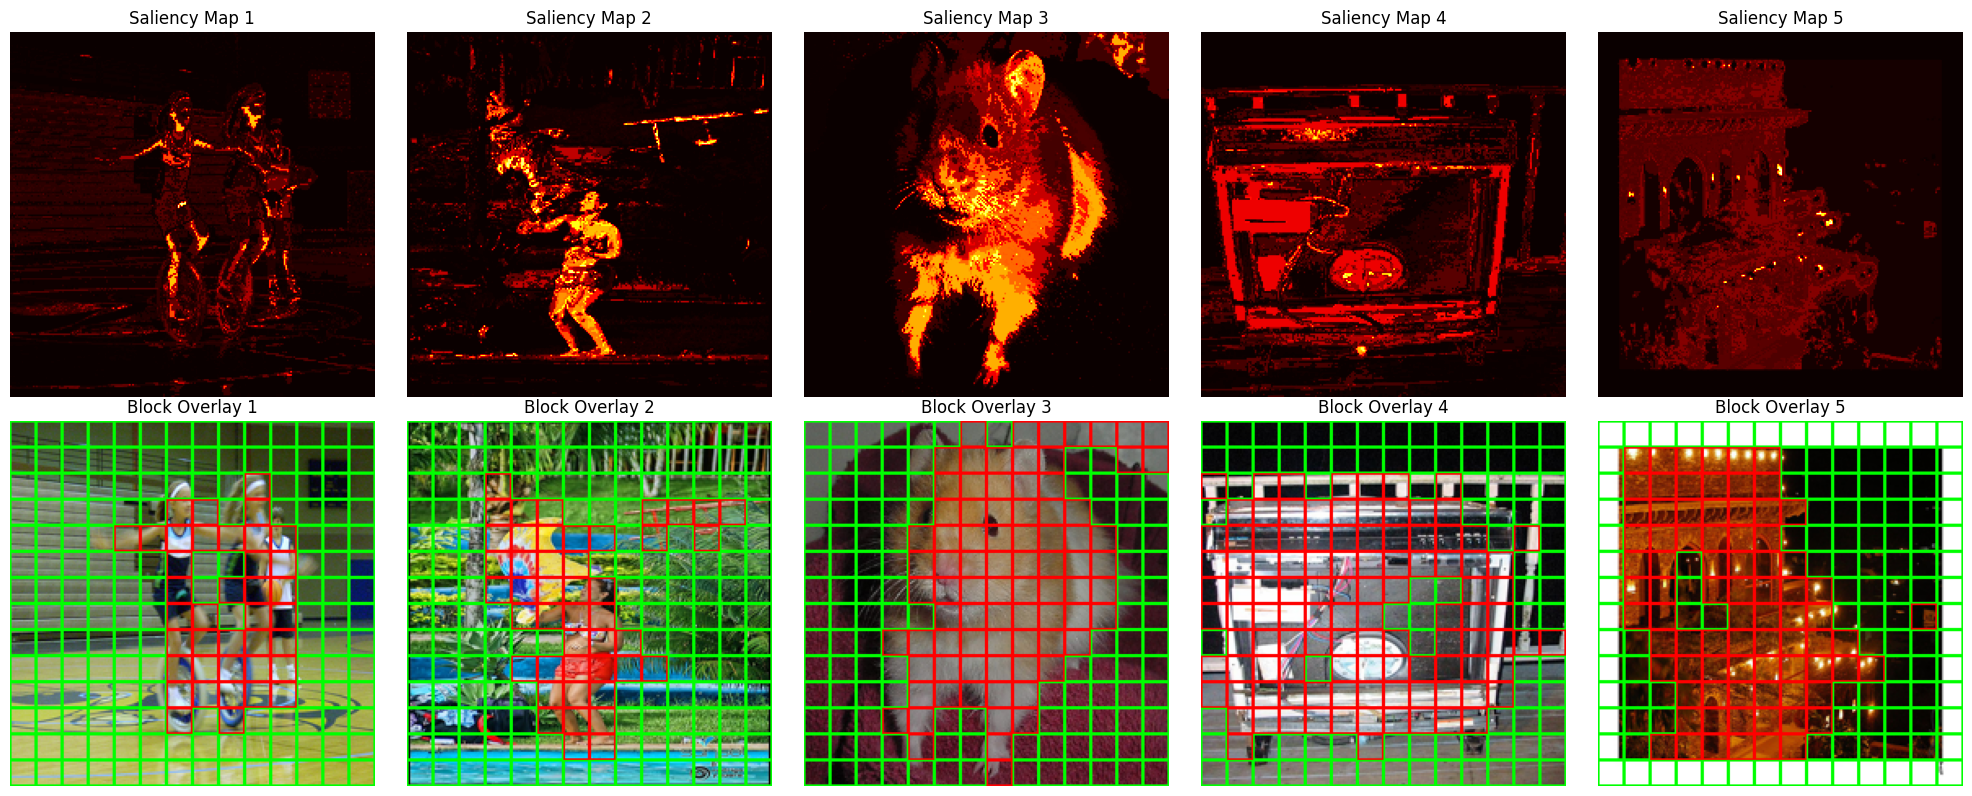

In [11]:
import matplotlib.pyplot as plt

def display_saliency_and_overlay(saliency_maps, overlay_images, titles=None):
    """
    Display saliency maps and overlay images in two rows:
    - Row 0: Saliency maps (hot colormap)
    - Row 1: Overlay images with green/red blocks

    Args:
        saliency_maps (list): List of saliency maps (HxW), normalized [0,1] or [0,255]
        overlay_images (list): List of overlay images (HxWx3), uint8
        titles (list): Optional list of titles for each image
    """
    num_images = len(saliency_maps)
    fig, axes = plt.subplots(2, num_images, figsize=(num_images * 4, 8))

    for i in range(num_images):
        sal_map = saliency_maps[i]
        overlay_img = overlay_images[i]

        # Normalize saliency map for display
        if sal_map.max() <= 1.0:
            sal_map_vis = (sal_map * 255).astype(np.uint8)
        else:
            sal_map_vis = sal_map.astype(np.uint8)

        # Saliency map
        axes[0, i].imshow(sal_map_vis, cmap='hot')
        axes[0, i].set_title(f"Saliency Map {i+1}" if not titles else titles[i])
        axes[0, i].axis('off')

        # Overlay image
        axes[1, i].imshow(overlay_img)
        axes[1, i].set_title(f"Block Overlay {i+1}" if not titles else titles[i])
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()


# Parameters
block_size = 16
threshold = 0.05

# Containers for masks and overlay images
block_masks = []
overlay_images = []

# Process each image and saliency map
for img, sal_map in zip(sample_images, saliency_maps):
    # Ensure image is uint8
    img_uint8 = (img * 255).astype(np.uint8) if img.max() <= 1.0 else img

    # Normalize saliency map if necessary
    sal_map_norm = sal_map / 255.0 if sal_map.max() > 1.0 else sal_map

    # Step 1: Compute block mask
    block_mask = compute_block_mask(sal_map_norm, block_size, threshold)
    block_masks.append(block_mask)

    # Step 2: Overlay block mask on image
    overlay_img = overlay_blocks_on_image(img_uint8, block_mask, block_size)
    overlay_images.append(overlay_img)

# Step 3: Display results
display_saliency_and_overlay(saliency_maps, overlay_images)

### Calculate Capacity

In [12]:
def calculate_embedding_capacity(block_mask, bits_per_block=4):
    """
    Calculate embedding capacity based on block mask and bits per block.
    
    Args:
        block_mask (numpy array): Binary mask of blocks (h_blocks x w_blocks)
        bits_per_block (int): Number of bits you can embed per block (default: 4)
    
    Returns:
        total_bits (int): Total embedding capacity in bits
    """
    num_good_blocks = np.sum(block_mask == 1)
    total_bits = num_good_blocks * bits_per_block
    print(f"Embedding capacity: {total_bits} bits ({num_good_blocks} blocks x {bits_per_block} bits/block)")
    return total_bits



### Generate Random Payload Bits

In [13]:
def generate_random_payload(num_bits):
    """
    Generate a random payload as a bitstream.
    
    Args:
        num_bits (int): Number of bits to generate
    
    Returns:
        payload_bits (numpy array): Array of 0s and 1s
    """
    payload_bits = np.random.randint(0, 2, size=num_bits, dtype=np.uint8)
    print(f"Generated random payload of {num_bits} bits.")
    return payload_bits


### Convert String Message to Bits

In [14]:
def string_to_bits(message):
    """
    Convert a string message to a bitstream (list of 0s and 1s).
    
    Args:
        message (str): Text message to convert
    
    Returns:
        payload_bits (numpy array): Bitstream of the message
    """
    byte_array = bytearray(message, 'utf-8')
    bits = []
    for byte in byte_array:
        bits.extend([int(bit) for bit in format(byte, '08b')])
    
    payload_bits = np.array(bits, dtype=np.uint8)
    print(f"Converted message '{message}' to {len(payload_bits)} bits.")
    return payload_bits


In [15]:
# Assume you already have block_masks from earlier

# Step 1: Calculate capacity for each image
bits_per_block = 4  # Or adjust based on your DCT embedding plan
capacities = [calculate_embedding_capacity(block_mask, bits_per_block=bits_per_block) for block_mask in block_masks]

# Step 2a: Generate random payloads for each image
random_payloads = [generate_random_payload(capacity) for capacity in capacities]

# Optional Step 2b: Convert string message to bits (if you want)
message = "War Ealge!"
message_payload = string_to_bits(message)

# Ensure message payload fits for each image
payloads = []
for capacity in capacities:
    if len(message_payload) > capacity:
        print("Message is too big! Trimming it to fit.")
        payload = message_payload[:capacity]
    else:
        payload = message_payload
    payloads.append(payload)

# Now you have payload bits ready to embed for each image!


Embedding capacity: 628 bits (157 blocks x 4 bits/block)
Embedding capacity: 604 bits (151 blocks x 4 bits/block)
Embedding capacity: 456 bits (114 blocks x 4 bits/block)
Embedding capacity: 356 bits (89 blocks x 4 bits/block)
Embedding capacity: 464 bits (116 blocks x 4 bits/block)
Generated random payload of 628 bits.
Generated random payload of 604 bits.
Generated random payload of 456 bits.
Generated random payload of 356 bits.
Generated random payload of 464 bits.
Converted message 'War Ealge!' to 80 bits.


## GAN

### Generate DCT Filters

Import Lib

In [16]:
import torch
import torch.nn as nn
import numpy as np

In [17]:
def create_dct_filters(block_size=16, channels=3):
    """
    Create DCT basis filters for a Conv2D layer.
    
    Args:
        block_size (int): Size of DCT block (default 16)
        channels (int): Number of image channels (default 3 for RGB)
    
    Returns:
        dct_filters (torch.Tensor): Tensor of DCT filters [num_filters, 1, H, W]
    """
    def alpha(p):
        return np.sqrt(1 / block_size) if p == 0 else np.sqrt(2 / block_size)
    
    dct_filters = np.zeros((block_size * block_size, block_size, block_size))

    for u in range(block_size):
        for v in range(block_size):
            for x in range(block_size):
                for y in range(block_size):
                    dct_filters[u * block_size + v, x, y] = (
                        alpha(u) * alpha(v) *
                        np.cos(((2 * x + 1) * u * np.pi) / (2 * block_size)) *
                        np.cos(((2 * y + 1) * v * np.pi) / (2 * block_size))
                    )
    
    # Expand filters to have channel dimension
    dct_filters = np.expand_dims(dct_filters, axis=1)  # Shape: [filters, 1, H, W]

    # Repeat filters for each channel (RGB)
    dct_filters = np.tile(dct_filters, (channels, 1, 1, 1))  # [filters*channels, 1, H, W]

    return torch.from_numpy(dct_filters).float()


### Conv2D DCT Layer in PyTorch

In [18]:
class DCTLayer(nn.Module):
    def __init__(self, block_size=16, channels=3):
        super(DCTLayer, self).__init__()
        self.block_size = block_size
        self.channels = channels

        dct_filters = create_dct_filters(block_size, channels)

        self.conv = nn.Conv2d(
            in_channels=channels,
            out_channels=channels * block_size * block_size,
            kernel_size=block_size,
            stride=block_size,
            padding=0,
            groups=channels,  # Separate filter sets per channel
            bias=False
        )

        self.conv.weight.data = dct_filters
        self.conv.weight.requires_grad = False  # Fixed DCT filters for now

    def forward(self, x):
        # Input shape: [batch_size, channels, height, width]
        dct_coeffs = self.conv(x)
        return dct_coeffs


### ConvTranspose2D IDCT Layer

In [19]:
class IDCTLayer(nn.Module):
    def __init__(self, block_size=16, channels=3):
        super(IDCTLayer, self).__init__()
        self.block_size = block_size
        self.channels = channels

        idct_filters = create_dct_filters(block_size, channels)

        self.deconv = nn.ConvTranspose2d(
            in_channels=channels * block_size * block_size,
            out_channels=channels,
            kernel_size=block_size,
            stride=block_size,
            padding=0,
            groups=channels,
            bias=False
        )

        self.deconv.weight.data = idct_filters
        self.deconv.weight.requires_grad = False  # Fixed for now

    def forward(self, x):
        # Input shape: [batch_size, channels * block_size * block_size, height // block_size, width // block_size]
        spatial = self.deconv(x)
        return spatial


### Test the DCT → Modify Mid-Freqs → IDCT Pipeline


In [20]:
def test_dct_idct_pipeline(image_tensor, block_size=16):
    dct_layer = DCTLayer(block_size=block_size, channels=image_tensor.shape[1])
    idct_layer = IDCTLayer(block_size=block_size, channels=image_tensor.shape[1])

    # Forward DCT
    dct_coeffs = dct_layer(image_tensor)

    # Modify mid-frequencies ONLY
    # You can adjust the slice depending on block_size
    start = 3
    end = 5
    # Modify only mid-band for each channel in each block
    dct_coeffs[:, :, start:end, start:end] += 1.0  # Example tweak, you can insert payload here

    # Inverse DCT
    recon_image = idct_layer(dct_coeffs)

    return recon_image


### Function to Embed Payload in Mid Frequencies

In [21]:
def embed_payload_in_dct(dct_coeffs, block_mask, payload_bits, block_size=16, mid_start=3, mid_end=5):
    """
    Embed payload bits into DCT mid-frequencies of low-saliency blocks.

    Args:
        dct_coeffs (torch.Tensor): [batch_size, channels * block_size^2, H // block_size, W // block_size]
        block_mask (torch.Tensor): [batch_size, H // block_size, W // block_size] (1 = embed, 0 = skip)
        payload_bits (torch.Tensor): [batch_size, total_bits]
        block_size (int): Block size (default 16)
        mid_start (int): Start index for mid-band embedding
        mid_end (int): End index for mid-band embedding
    
    Returns:
        stego_dct_coeffs (torch.Tensor): Modified DCT coefficients with embedded payload
    """
    batch_size, _, h_blocks, w_blocks = dct_coeffs.shape
    coeffs_per_block = block_size * block_size
    channels = dct_coeffs.shape[1] // coeffs_per_block

    # Clone original DCT coeffs to modify
    stego_dct_coeffs = dct_coeffs.clone()

    bit_index = 0  # Current bit we're embedding

    for b in range(batch_size):
        for i in range(h_blocks):
            for j in range(w_blocks):
                # Only embed if this block is marked as OK (low saliency)
                if block_mask[b, i, j] == 1:
                    # Calculate block position in DCT coefficients
                    for c in range(channels):
                        # Calculate the starting index for this channel's block
                        base_idx = c * coeffs_per_block

                        for u in range(mid_start, mid_end):
                            for v in range(mid_start, mid_end):
                                flat_idx = u * block_size + v
                                coeff_idx = base_idx + flat_idx

                                # Check if we have bits left to embed
                                if bit_index >= payload_bits.shape[1]:
                                    break

                                # Embed: simple example -> LSB replacement style logic
                                original_coeff = stego_dct_coeffs[b, coeff_idx, i, j]

                                # Embed the bit into the coefficient
                                new_coeff = (original_coeff.floor()) + payload_bits[b, bit_index].float()
                                stego_dct_coeffs[b, coeff_idx, i, j] = new_coeff

                                bit_index += 1
                        if bit_index >= payload_bits.shape[1]:
                            break
                if bit_index >= payload_bits.shape[1]:
                    break
            if bit_index >= payload_bits.shape[1]:
                break
    
    print(f"Embedded {bit_index} bits into the DCT coefficients.")
    return stego_dct_coeffs


### Full DCT → Embed → IDCT Flow


In [22]:
def embed_payload_and_reconstruct(image_tensor, block_mask, payload_bits, block_size=16, mid_start=3, mid_end=5):
    """
    Full pipeline: DCT → Embed payload → IDCT

    Args:
        image_tensor (torch.Tensor): Cover image [batch_size, channels, H, W]
        block_mask (torch.Tensor): Block mask [batch_size, H//block_size, W//block_size]
        payload_bits (torch.Tensor): Payload bitstream [batch_size, total_bits]
    
    Returns:
        stego_image (torch.Tensor): Stego image [batch_size, channels, H, W]
    """
    dct_layer = DCTLayer(block_size=block_size, channels=image_tensor.shape[1])
    idct_layer = IDCTLayer(block_size=block_size, channels=image_tensor.shape[1])

    # 1. DCT transform
    dct_coeffs = dct_layer(image_tensor)

    # 2. Embed payload bits into mid frequencies
    stego_dct_coeffs = embed_payload_in_dct(
        dct_coeffs,
        block_mask,
        payload_bits,
        block_size=block_size,
        mid_start=mid_start,
        mid_end=mid_end
    )

    # 3. Inverse DCT to reconstruct the stego image
    stego_image = idct_layer(stego_dct_coeffs)

    return stego_image


### Generator Class

In [23]:
import torch
import torch.nn as nn

class StegoGenerator(nn.Module):
    def __init__(self, block_size=16, mid_start=3, mid_end=5, channels=3):
        super(StegoGenerator, self).__init__()
        self.block_size = block_size
        self.mid_start = mid_start
        self.mid_end = mid_end
        self.channels = channels

        self.dct_layer = DCTLayer(block_size=self.block_size, channels=self.channels)
        self.idct_layer = IDCTLayer(block_size=self.block_size, channels=self.channels)

    def forward(self, cover_image, block_mask, payload_bits):
        """
        Args:
            cover_image (tensor): [batch, channels, H, W]
            block_mask (tensor): [batch, H//block, W//block]
            payload_bits (tensor): [batch, total_bits]
        
        Returns:
            stego_image (tensor): Stego image [batch, channels, H, W]
        """
        # Step 1: DCT Transform
        dct_coeffs = self.dct_layer(cover_image)

        # Step 2: Embed Payload
        stego_dct_coeffs = embed_payload_in_dct(
            dct_coeffs,
            block_mask,
            payload_bits,
            block_size=self.block_size,
            mid_start=self.mid_start,
            mid_end=self.mid_end
        )

        # Step 3: IDCT Transform (Reconstruct Stego Image)
        stego_image = self.idct_layer(stego_dct_coeffs)

        return stego_image


## GNCNN Code (pytorch) for dis

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class GaussianActivation(nn.Module):
    def __init__(self):
        super(GaussianActivation, self).__init__()

    def forward(self, x):
        return torch.exp(-torch.pow(x, 2))


### GNCNN Discriminator

In [25]:
class GNCNN_Discriminator(nn.Module):
    def __init__(self, input_channels=3):
        super(GNCNN_Discriminator, self).__init__()

        # First convolutional layer - suppresses high frequencies
        self.conv1 = nn.Conv2d(input_channels, 8, kernel_size=5, stride=1, padding=2)
        self.gauss1 = GaussianActivation()

        # Second convolutional layer
        self.conv2 = nn.Conv2d(8, 16, kernel_size=5, stride=1, padding=2)
        self.gauss2 = GaussianActivation()
        self.pool2 = nn.AvgPool2d(kernel_size=2)

        # Third convolutional layer
        self.conv3 = nn.Conv2d(16, 32, kernel_size=5, stride=1, padding=2)
        self.gauss3 = GaussianActivation()
        self.pool3 = nn.AvgPool2d(kernel_size=2)

        # Fourth convolutional layer
        self.conv4 = nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=2)
        self.gauss4 = GaussianActivation()
        self.pool4 = nn.AvgPool2d(kernel_size=2)

        # Fifth convolutional layer
        self.conv5 = nn.Conv2d(64, 128, kernel_size=5, stride=1, padding=2)
        self.gauss5 = GaussianActivation()
        self.pool5 = nn.AvgPool2d(kernel_size=2)

        # Fully connected classifier
        self.fc1 = nn.Linear(128 * 14 * 14, 256)  # Assuming input image 224x224
        self.fc2 = nn.Linear(256, 1)

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Input x shape: [batch, channels, height, width]

        x = self.conv1(x)
        x = self.gauss1(x)

        x = self.conv2(x)
        x = self.gauss2(x)
        x = self.pool2(x)

        x = self.conv3(x)
        x = self.gauss3(x)
        x = self.pool3(x)

        x = self.conv4(x)
        x = self.gauss4(x)
        x = self.pool4(x)

        x = self.conv5(x)
        x = self.gauss5(x)
        x = self.pool5(x)

        # Flatten for FC layer
        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        out = self.sigmoid(x)

        return out


### Adversarial Loss (Binary Cross-Entropy)


In [26]:
adversarial_loss = nn.BCELoss()  # Binary Cross-Entropy Loss


### Distortion Loss (MSE or SSIM)

In [27]:
distortion_loss = nn.MSELoss()

### Combine loss - ( if we wnat to can ad payload loss)

L_total = L_adv + λ1 * L_distortion

### Generator Loss

In [28]:
def generator_loss_fn(discriminator_output, stego_image, cover_image, lambda_distortion=0.5):
    """
    Generator loss = Adversarial loss + λ1 * Distortion loss
    
    Args:
        discriminator_output: Output from Discriminator on stego image
        stego_image: Generated stego image
        cover_image: Original cover image
        lambda_distortion: Weight for distortion loss
    
    Returns:
        Total Generator loss
    """
    # Adversarial loss (we want discriminator to think stego is real → label 0)
    valid_labels = torch.zeros_like(discriminator_output)
    adv_loss = adversarial_loss(discriminator_output, valid_labels)

    # Distortion loss (MSE)
    dist_loss = distortion_loss(stego_image, cover_image)

    # Total loss
    total_loss = adv_loss + lambda_distortion * dist_loss

    return total_loss


### Discriminator Loss

In [29]:
def discriminator_loss_fn(d_cover, d_stego):
    """
    Discriminator loss = classify cover as real (0), stego as fake (1)
    
    Args:
        d_cover: Discriminator output on cover image
        d_stego: Discriminator output on stego image
    
    Returns:
        Total Discriminator loss
    """
    # Real covers → label 0
    real_labels = torch.zeros_like(d_cover)
    loss_real = adversarial_loss(d_cover, real_labels)

    # Stego images → label 1
    fake_labels = torch.ones_like(d_stego)
    loss_fake = adversarial_loss(d_stego, fake_labels)

    total_loss = (loss_real + loss_fake) / 2.0

    return total_loss


### ADam optimizer

In [30]:
# Define device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize models
generator = StegoGenerator().to(device)
discriminator = GNCNN_Discriminator().to(device)

# Example optimizers
generator_optimizer = torch.optim.Adam(generator.parameters(), lr=1e-4, betas=(0.5, 0.999))
discriminator_optimizer = torch.optim.Adam(discriminator.parameters(), lr=1e-4, betas=(0.5, 0.999))


Exmaple Data

In [31]:
# from torch.utils.data import Dataset, DataLoader
# import torch
# import random

# class StegoDataset(Dataset):
#     def __init__(self, image_paths, block_size=16, threshold=0.3, bits_per_block=4, transform=None):
#         """
#         Args:
#             image_paths (list): List of file paths to cover images
#             block_size (int): Size of blocks (default 16)
#             threshold (float): Saliency threshold for masking
#             bits_per_block (int): How many bits to embed per block
#             transform (callable, optional): Optional transform to apply to images
#         """
#         self.image_paths = image_paths
#         self.block_size = block_size
#         self.threshold = threshold
#         self.bits_per_block = bits_per_block
#         self.transform = transform

#     def __len__(self):
#         return len(self.image_paths)

#     def __getitem__(self, idx):
#         # Step 1: Load cover image
#         image_path = self.image_paths[idx]
#         image = self.load_image(image_path)

#         # Step 2: Generate saliency map (or load precomputed one)
#         saliency_map = self.generate_saliency_map(image)

#         # Step 3: Compute block mask from saliency
#         block_mask = compute_block_mask(saliency_map, block_size=self.block_size, threshold=self.threshold)

#         # Step 4: Calculate embedding capacity based on block mask
#         capacity_bits = calculate_embedding_capacity(block_mask, bits_per_block=self.bits_per_block)

#         # Step 5: Generate payload bits
#         payload_bits = generate_random_payload(capacity_bits)

#         # Step 6: Convert everything to torch.Tensor
#         image_tensor = self.to_tensor(image)
#         block_mask_tensor = torch.tensor(block_mask, dtype=torch.float32)
#         payload_bits_tensor = torch.tensor(payload_bits, dtype=torch.float32)

#         return {
#             'cover_images': image_tensor,
#             'saliency_masks': block_mask_tensor,
#             'payload_bits': payload_bits_tensor
#         }

#     def load_image(self, path):
#         # Example: Use PIL and torchvision transforms
#         from PIL import Image
#         img = Image.open(path).convert('RGB').resize((224, 224))

#         if self.transform:
#             img = self.transform(img)
#         else:
#             img = torch.from_numpy(np.array(img)).float() / 255.0  # Normalize to [0, 1]
#             img = img.permute(2, 0, 1)  # HWC → CHW
        
#         return img

#     def generate_saliency_map(self, image):
#         # Use your existing saliency generation code
#         # Dummy random saliency map for this example:
#         h, w = image.shape[1], image.shape[2]
#         saliency_map = np.random.rand(h, w).astype(np.float32)  # Replace with real saliency computation
#         return saliency_map


### Create the datasetcode

In [32]:
import os
import glob
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms

# Assuming you're using FasaSaliencyMapping from DeepGaze (as before)
from deepgaze.saliency_map import FasaSaliencyMapping  

class StegoDataset(Dataset):
    def __init__(self, image_folder, block_size=16, payload_bits_per_block=4, saliency_threshold=0.3, transform=None):
        self.image_paths = glob.glob(os.path.join(image_folder, '*.*'))
        self.block_size = block_size
        self.payload_bits_per_block = payload_bits_per_block
        self.saliency_threshold = saliency_threshold
        self.transform = transform
        
        # Saliency model (re-init if needed for each image)
        self.saliency_model = FasaSaliencyMapping(image_h=224, image_w=224)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # 1. Load Image
        img_path = self.image_paths[idx]
        img = Image.open(img_path).convert("RGB")
        img = img.resize((224, 224))  # Or your desired size
        img_np = np.array(img)

        # 2. Transform to tensor and normalize [0, 1]
        if self.transform:
            img_tensor = self.transform(img)
        else:
            img_tensor = transforms.ToTensor()(img)  # Shape [C, H, W]

        # 3. Generate saliency map
        saliency_map = self.saliency_model.returnMask((img_np).astype(np.uint8), tot_bins=8, format='RGB')
        saliency_map_norm = cv2.normalize(saliency_map, None, 0, 1.0, cv2.NORM_MINMAX)

        # 4. Generate block mask from saliency map
        block_mask = self.generate_block_mask(saliency_map_norm)

        # 5. Calculate embedding capacity
        capacity_bits = self.calculate_capacity(block_mask)

        # 6. Generate payload bits (random for now)
        payload_bits = self.generate_payload(capacity_bits)

        # Convert everything to torch tensors
        block_mask_tensor = torch.from_numpy(block_mask).float()  # Shape [H//block, W//block]
        payload_bits_tensor = torch.from_numpy(payload_bits).float()  # Shape [capacity_bits]

        return img_tensor, block_mask_tensor, payload_bits_tensor

    def generate_block_mask(self, saliency_map):
        """
        Generate block-wise mask based on saliency map.
        """
        h, w = saliency_map.shape
        h_blocks = h // self.block_size
        w_blocks = w // self.block_size

        mask = np.zeros((h_blocks, w_blocks), dtype=np.uint8)

        for i in range(h_blocks):
            for j in range(w_blocks):
                y_start = i * self.block_size
                x_start = j * self.block_size
                block = saliency_map[y_start:y_start + self.block_size, x_start:x_start + self.block_size]
                avg_saliency = np.mean(block)

                if avg_saliency < self.saliency_threshold:
                    mask[i, j] = 1  # Good for embedding

        return mask

    def calculate_capacity(self, block_mask):
        """
        Calculate total embedding capacity (bits) from block mask.
        """
        num_good_blocks = np.sum(block_mask == 1)
        total_bits = num_good_blocks * self.payload_bits_per_block
        return int(total_bits)

    def generate_payload(self, num_bits):
        """
        Generate a random payload bitstream of size num_bits.
        """
        payload_bits = np.random.randint(0, 2, size=num_bits, dtype=np.uint8)
        return payload_bits


### DataLoader

In [33]:
from torch.utils.data import DataLoader

# Dataset params
image_folder = "data/imagenet/train"  # Change to your folder path
batch_size = 4  # Adjust as needed

dataset = StegoDataset(
    image_folder=image_folder,
    block_size=16,
    payload_bits_per_block=4,
    saliency_threshold=0.3
)

dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)

# Iterate through batches
for batch_idx, (cover_images, block_masks, payload_bits) in enumerate(dataloader):
    print(f"Batch {batch_idx + 1}")
    print("Cover Images:", cover_images.shape)  # [batch, channels, H, W]
    print("Block Masks:", block_masks.shape)    # [batch, H//block, W//block]
    print("Payload Bits:", payload_bits.shape)  # [batch, total_bits]
    # Break early just to test
    if batch_idx == 0:
        break


RuntimeError: Caught RuntimeError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/home/btm0050/anaconda3/envs/stegano_gan/lib/python3.8/site-packages/torch/utils/data/_utils/worker.py", line 309, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
  File "/home/btm0050/anaconda3/envs/stegano_gan/lib/python3.8/site-packages/torch/utils/data/_utils/fetch.py", line 55, in fetch
    return self.collate_fn(data)
  File "/home/btm0050/anaconda3/envs/stegano_gan/lib/python3.8/site-packages/torch/utils/data/_utils/collate.py", line 317, in default_collate
    return collate(batch, collate_fn_map=default_collate_fn_map)
  File "/home/btm0050/anaconda3/envs/stegano_gan/lib/python3.8/site-packages/torch/utils/data/_utils/collate.py", line 174, in collate
    return [collate(samples, collate_fn_map=collate_fn_map) for samples in transposed]  # Backwards compatibility.
  File "/home/btm0050/anaconda3/envs/stegano_gan/lib/python3.8

## Training Loop Code (Step-by-Step)


### Set up losses and optimizers

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Loss functions (we did this earlier)
adversarial_loss = nn.BCELoss()
distortion_loss = nn.MSELoss()

# Optimizers
generator_optimizer = optim.Adam(generator.parameters(), lr=1e-4, betas=(0.5, 0.999))
discriminator_optimizer = optim.Adam(discriminator.parameters(), lr=1e-4, betas=(0.5, 0.999))


### Training loop

In [ ]:
import tqdm  # For pretty progress bars

num_epochs = 50
lambda_distortion = 0.5  # Weight for distortion loss

# Loop through epochs
for epoch in range(num_epochs):
    generator.train()
    discriminator.train()

    loop = tqdm.tqdm(dataloader, leave=True)

    for batch_idx, (cover_images, block_masks, payload_bits) in enumerate(loop):
        batch_size = cover_images.size(0)

        # Move data to GPU (if available)
        cover_images = cover_images.to(device)
        block_masks = block_masks.to(device)
        payload_bits = payload_bits.to(device)

        # ==========================
        # 1. Train Discriminator
        # ==========================
        discriminator_optimizer.zero_grad()

        # Real covers → label 0
        real_labels = torch.zeros((batch_size, 1), device=device)

        # Generate stego images using Generator
        stego_images = generator(cover_images, block_masks, payload_bits)

        # Get Discriminator outputs
        d_real = discriminator(cover_images)
        d_fake = discriminator(stego_images.detach())  # Detach so G isn't updated here

        # Discriminator loss
        d_loss = discriminator_loss_fn(d_real, d_fake)
        d_loss.backward()
        discriminator_optimizer.step()

        # ==========================
        # 2. Train Generator
        # ==========================
        generator_optimizer.zero_grad()

        # Get Discriminator prediction on stego images (updated after D step)
        d_fake_for_g = discriminator(stego_images)

        # Generator loss (adversarial + distortion)
        g_loss = generator_loss_fn(d_fake_for_g, stego_images, cover_images, lambda_distortion=lambda_distortion)
        g_loss.backward()
        generator_optimizer.step()

        # ==========================
        # 3. Logging
        # ==========================
        loop.set_description(f"Epoch [{epoch+1}/{num_epochs}]")
        loop.set_postfix(D_Loss=d_loss.item(), G_Loss=g_loss.item())


### Vizualize

In [ ]:
if (epoch + 1) % 10 == 0:
    torch.save(generator.state_dict(), f'generator_epoch_{epoch+1}.pth')
    torch.save(discriminator.state_dict(), f'discriminator_epoch_{epoch+1}.pth')
    print(f"Saved models at epoch {epoch+1}")


# Convert stego image tensor to NumPy and save/display
import torchvision.utils as vutils

if (epoch + 1) % 5 == 0:
    vutils.save_image(stego_images.data, f'stego_epoch_{epoch+1}.png', normalize=True)
